# Explore here

In [26]:
import json

In [27]:
# Your code here
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Step 2: Exploración y limpieza de datos

In [28]:
# Obtener las dimensiones
total_data.shape

(48895, 16)

El Dataframe tiene 48,895 filas y  16 variables en columnas.

In [29]:
# Obtener información de las columnas con valores nulos
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

De los datos que tenemos en las columnas que se encuentran en mayor proporción Valores Nulos son: last_review y reviews_per_month

Así como el Dtype nos da los siguientes datos:

*   8 son Características Categóricas (id, name, host_id, host_name, neighbourhood_group, neighbourhood, room_type, availability_365)
*   8 son Características numéricas:(latitude, longitude, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count)

In [30]:
##Eliminar duplicados : Cuántas filas duplicadas existen?
print(f"La cantidad de nombres duplicados son: {total_data['name'].duplicated().sum()}")
print(f"La cantidad de host_id duplicados son: {total_data['host_id'].duplicated().sum()}")
print(f"La cantidad de id_records duplicados son: {total_data['id'].duplicated().sum()}")

La cantidad de nombres duplicados son: 989
La cantidad de host_id duplicados son: 11438
La cantidad de id_records duplicados son: 0


No vamos a eliminar ningún dato duplicado de `name`lo cual significa que posiblemente los anuncios para los que se publicita colocan los mismos términos, por los datos duplicados de `host_id` aparentemente son aquellos host que tienen varios acomodaciones de airbnb publicadas. Por ser información que puede ser posteriormente necesaria no se tomará la decisión de eliminarla.

## PASO 3: Análisis de variables univariante

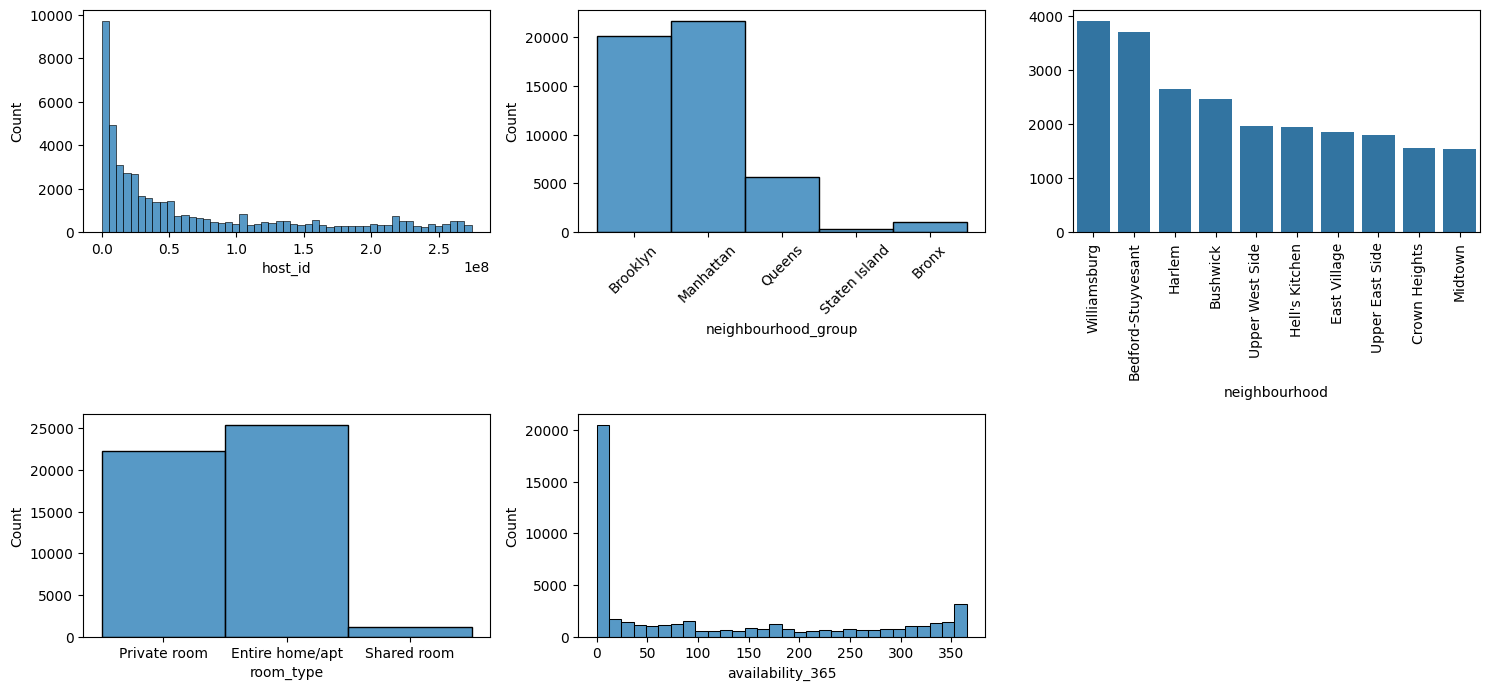

In [31]:
#PASO. 3: Análisis de variables univariante
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 3, figsize=(15, 7))

# Create Histogram
sns.histplot(ax = axis[0,0], data = total_data, x = "host_id")

sns.histplot(ax = axis[0,1], data = total_data, x = "neighbourhood_group")
axis[0,1].tick_params(axis='x', rotation=45)

#Al no apreciarse los barrios y sus precios he decidido colocar los 10 con mayor puntuación
top10 = total_data['neighbourhood'].value_counts().head(10)
sns.barplot(ax = axis[0,2], x=top10.index, y=top10.values)

axis[0,2].tick_params(axis='x', rotation=90)
sns.histplot(ax = axis[1,0], data = total_data, x = "room_type")
sns.histplot(ax = axis[1,1], data = total_data, x = "availability_365")
fig.delaxes(axis[1, 2])

plt.tight_layout()
# Show the plot
plt.show()

INTERPRETACIÓN:

-En el Primer Histograma de la izquierda hay muchos anfitriones host_id únicos con pocos anuncios, y unos pocos anfitriones con muchos anuncios.Esto sugiere que la mayoría son anfitriones individuales, pero también hay empresas o gestores con múltiples propiedades.

-En el Segundo Histograma hay un grupo de neighbourhood_group que domina claramente en número de anuncios a más de 20 000. Lo que quiere decir que esa zona es la más popular o tiene más oferta mientras que las demás tienen una menor presencia.

-En el Tercer Histograma hay una gran variedad de vecindarios, pero solo unos pocos concentran la mayoría de los anuncios (hasta 4,000) Dentro de los 10 primeros se ha considerado Williamsburg y empieza a decrecer en Harlem hasta Midtown.

-Para el Cuarto Histograma se refiere al tipo de alquiler donde el más común es la vivienda completa, seguido por habitación privada. De estas dos existe una gran diferencia con las habitaciones compartidas que tienen inferiores ingresos.

-Por último, en el Histograma de disponibilidad se puede visualizar que hay picos en los extremos: Muchos anuncios que no están disponibles en absoluto (0 días).Esto sugiere que publican ocasionalmente o han abandonado el anuncio.

## Análisis sobre variables numéricas

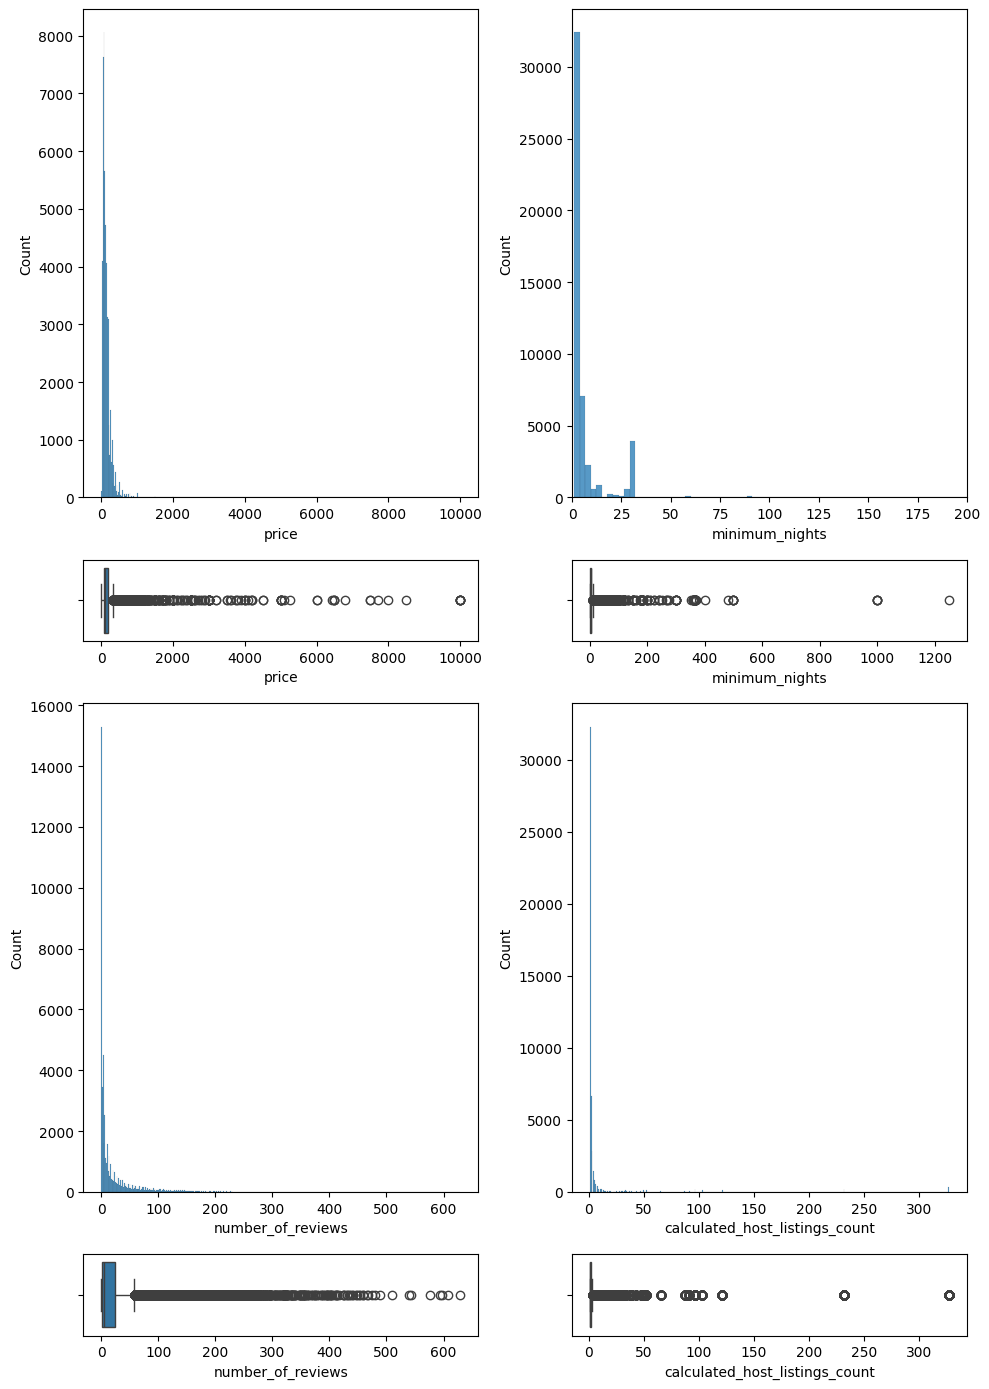

In [32]:
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "price")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "price")

sns.histplot(ax = axis[0, 1], data = total_data, x = "minimum_nights").set_xlim(0, 200)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "minimum_nights")

sns.histplot(ax = axis[2, 0], data = total_data, x = "number_of_reviews")
sns.boxplot(ax = axis[3, 0], data = total_data, x = "number_of_reviews")

sns.histplot(ax = axis[2,1], data = total_data, x = "calculated_host_listings_count")
sns.boxplot(ax = axis[3, 1], data = total_data, x = "calculated_host_listings_count")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

INTERPRETACIÓN:

-Para el gráfico de los precios existe una cola larga que se extiende hasta precios muy altos (hasta 10,000), lo que indica la presencia de outliers: Pocos alojamientos de lujo y en su mayoría son económicos

-En el segundo gráfico, la mayoría de usuarios se quedan como mínimo una noche hasta 20 noches y va decreciendo abismalmente hasta una cola que llega hasta 200 noches.

-El tercer histograma refleja que la mayoría de anuncios tienen pocas reseñas y existe una distribución altamente sesgada a la derecha, con pocos alojamientos acumulando muchas reseñas.

-Por último, la mayoría de anunciantes tienen una o muy pocas propiedades. También existe una distribución sesgada a la derecha, con predominancia de anfitriones individuales.

### PASO 4: Análisis de variable multivariante

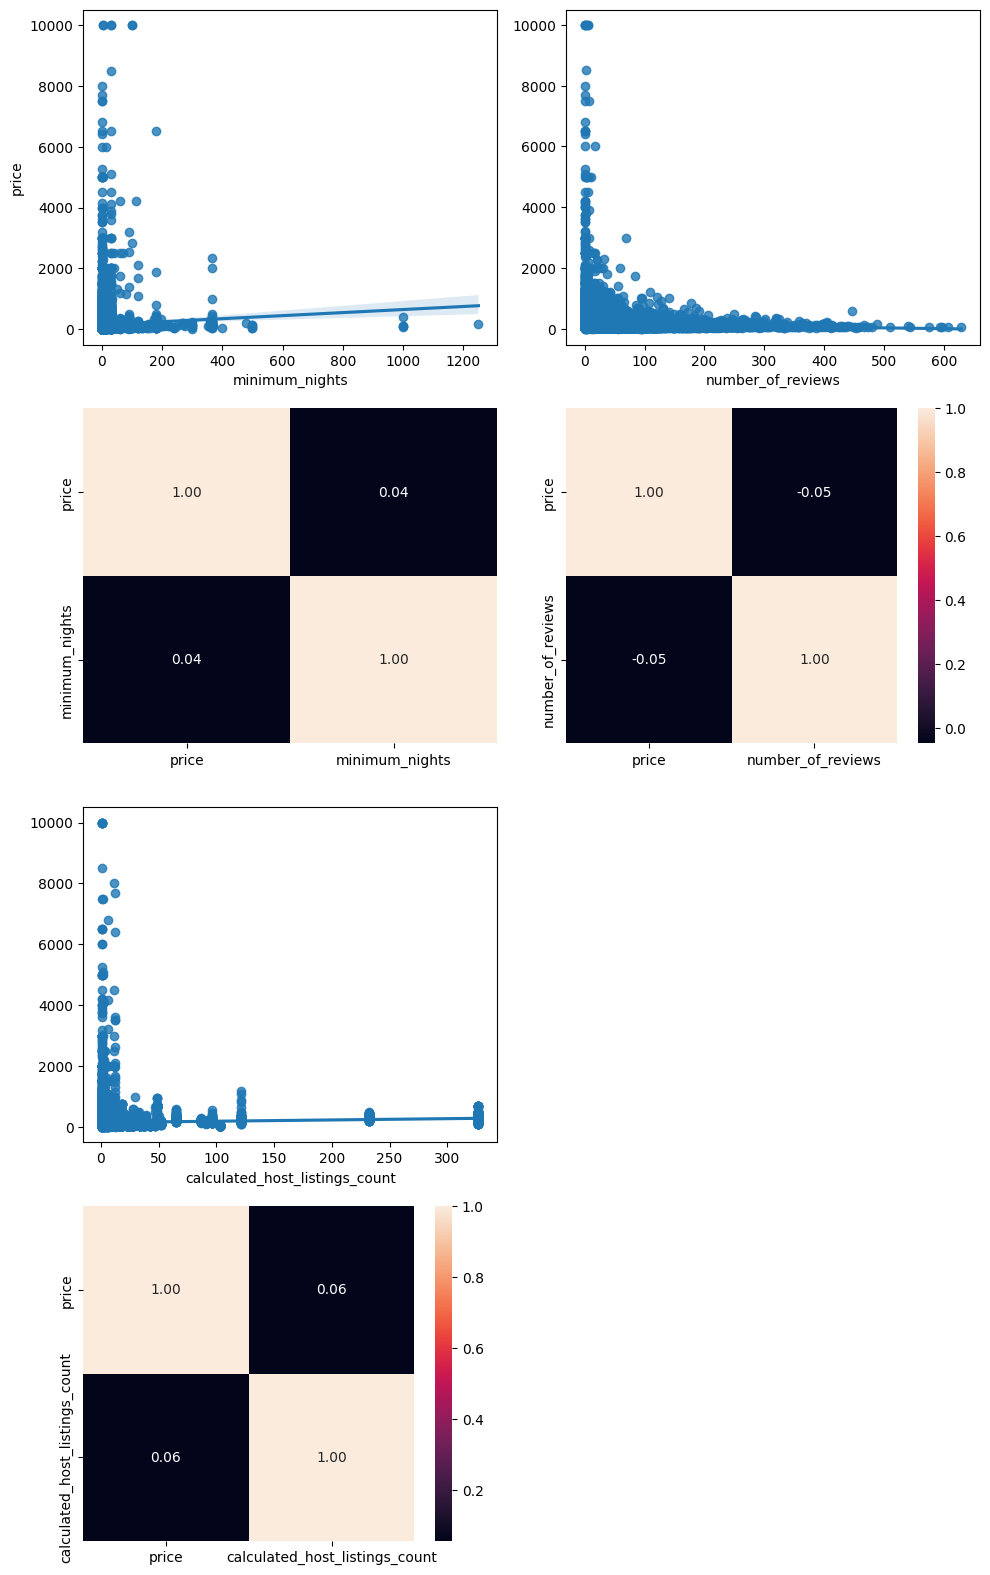

In [33]:
# Numerical - Numerical Analysis

# Create subplot canvas
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

# Create Plates
sns.regplot(ax = axis[0, 0], data = total_data, x = "minimum_nights", y = "price")
sns.heatmap(total_data[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "number_of_reviews", y = "price").set(ylabel = None)
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "calculated_host_listings_count", y = "price").set(ylabel = None)
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

-EN LA PRIMERA COORELACIÓN ENTRE PRECIO Y NÚMERO DE NOCHES :No existe relación entre el precio y el número mínimo de noches.

-EN LA SEGUNDA COORELACIÓN ENTRE PRECIO Y RESEÑAS: No existe relación entre el número de reseñas y el precio.

-EN LA TERCERA COORELACIÓN ENTRE PRECIO Y LA CANTIDAD DE ALOJAMIENTOS GESTIONADOS: Los anfitriones con muchos alojamientos tienden a tener precios más uniformes y moderados.

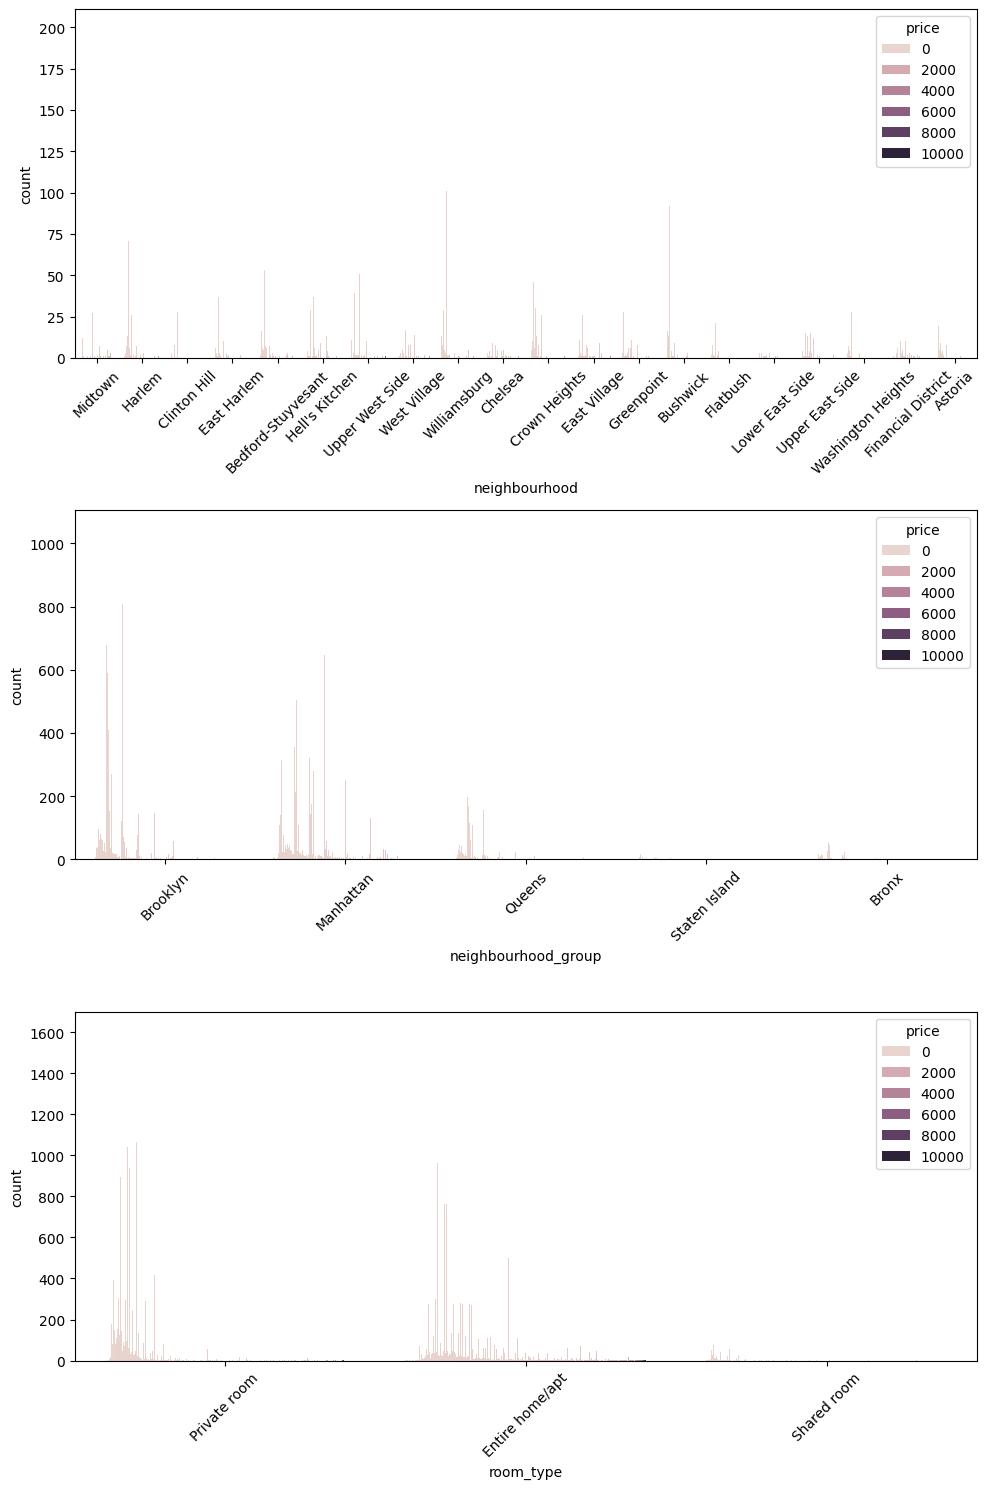

In [34]:
# Obtener los 20 neighbourhood más frecuentes
top20_neigh = total_data['neighbourhood'].value_counts().head(20).index

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Gráfico 1: solo los 20 barrios más comunes
sns.countplot(
    ax=axes[0],
    data=total_data[total_data['neighbourhood'].isin(top20_neigh)],
    x="neighbourhood",
    hue="price"
)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: sin cambios
sns.countplot(
    ax=axes[1],
    data=total_data,
    x="neighbourhood_group",
    hue="price"
)
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3: sin cambios
sns.countplot(
    ax=axes[2],
    data=total_data,
    x="room_type",
    hue="price"
)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


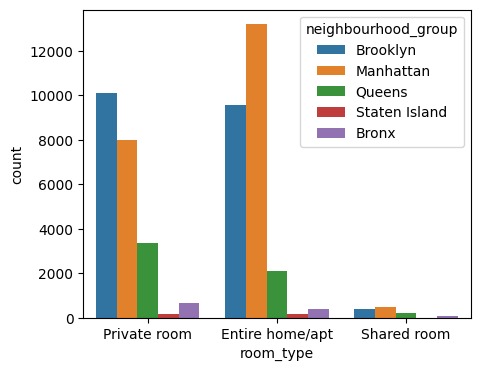

In [35]:
##Análisis Categórico-Categórico

fig, axis = plt.subplots(figsize = (5, 4))

sns.countplot(data = total_data, x = "room_type", hue = "neighbourhood_group")

# Show the plot
plt.show()

Manhattan tiene la zona con más alojamiento de casa o apatarmentos enteros alquilados por usuarios
Los usuarios prefieren una habitación privada en la zona de Brooklyn
En general, Staten Island es de las zonas menos alquiladas o que la prefieren menos.
Y, respecto a habitaciones compartidas se quedan muy poco alquiladas y nula para la zona de Staten Island

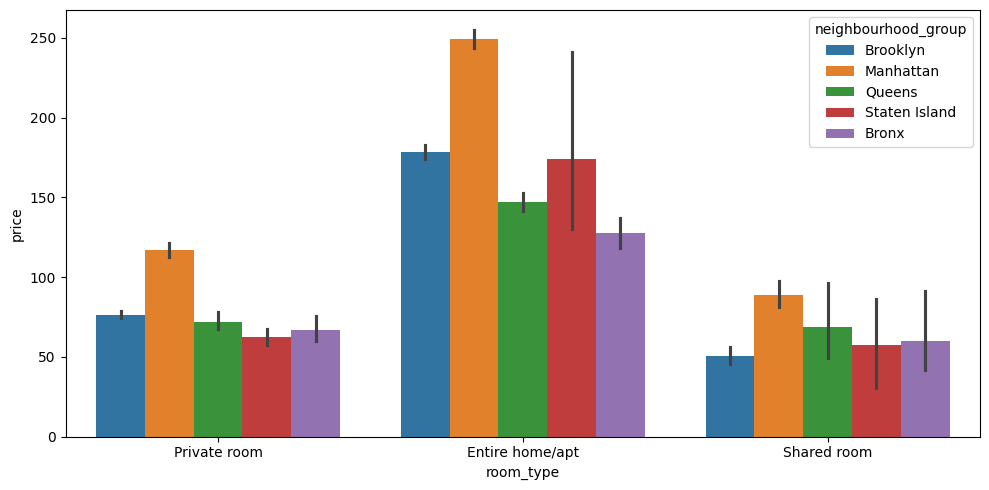

In [36]:
## Combinaciones de grupos de barrios con varias predictoras: precio y tipo de habitación
fig, axis = plt.subplots(figsize=(10, 5))

sns.barplot(ax=axis, data=total_data, x="room_type", y="price", hue="neighbourhood_group")

plt.tight_layout()
plt.show()


Manhattan tiene la zona con más alojamiento de casa o apatarmentos enteros alquilados por usuarios
Los usuarios prefieren una habitación privada en la zona de Brooklyn
En general, Staten Island es de las zonas menos alquiladas o que la prefieren menos.
Y, respecto a habitaciones compartidas se quedan muy poco alquiladas y nula para la zona de Staten Island

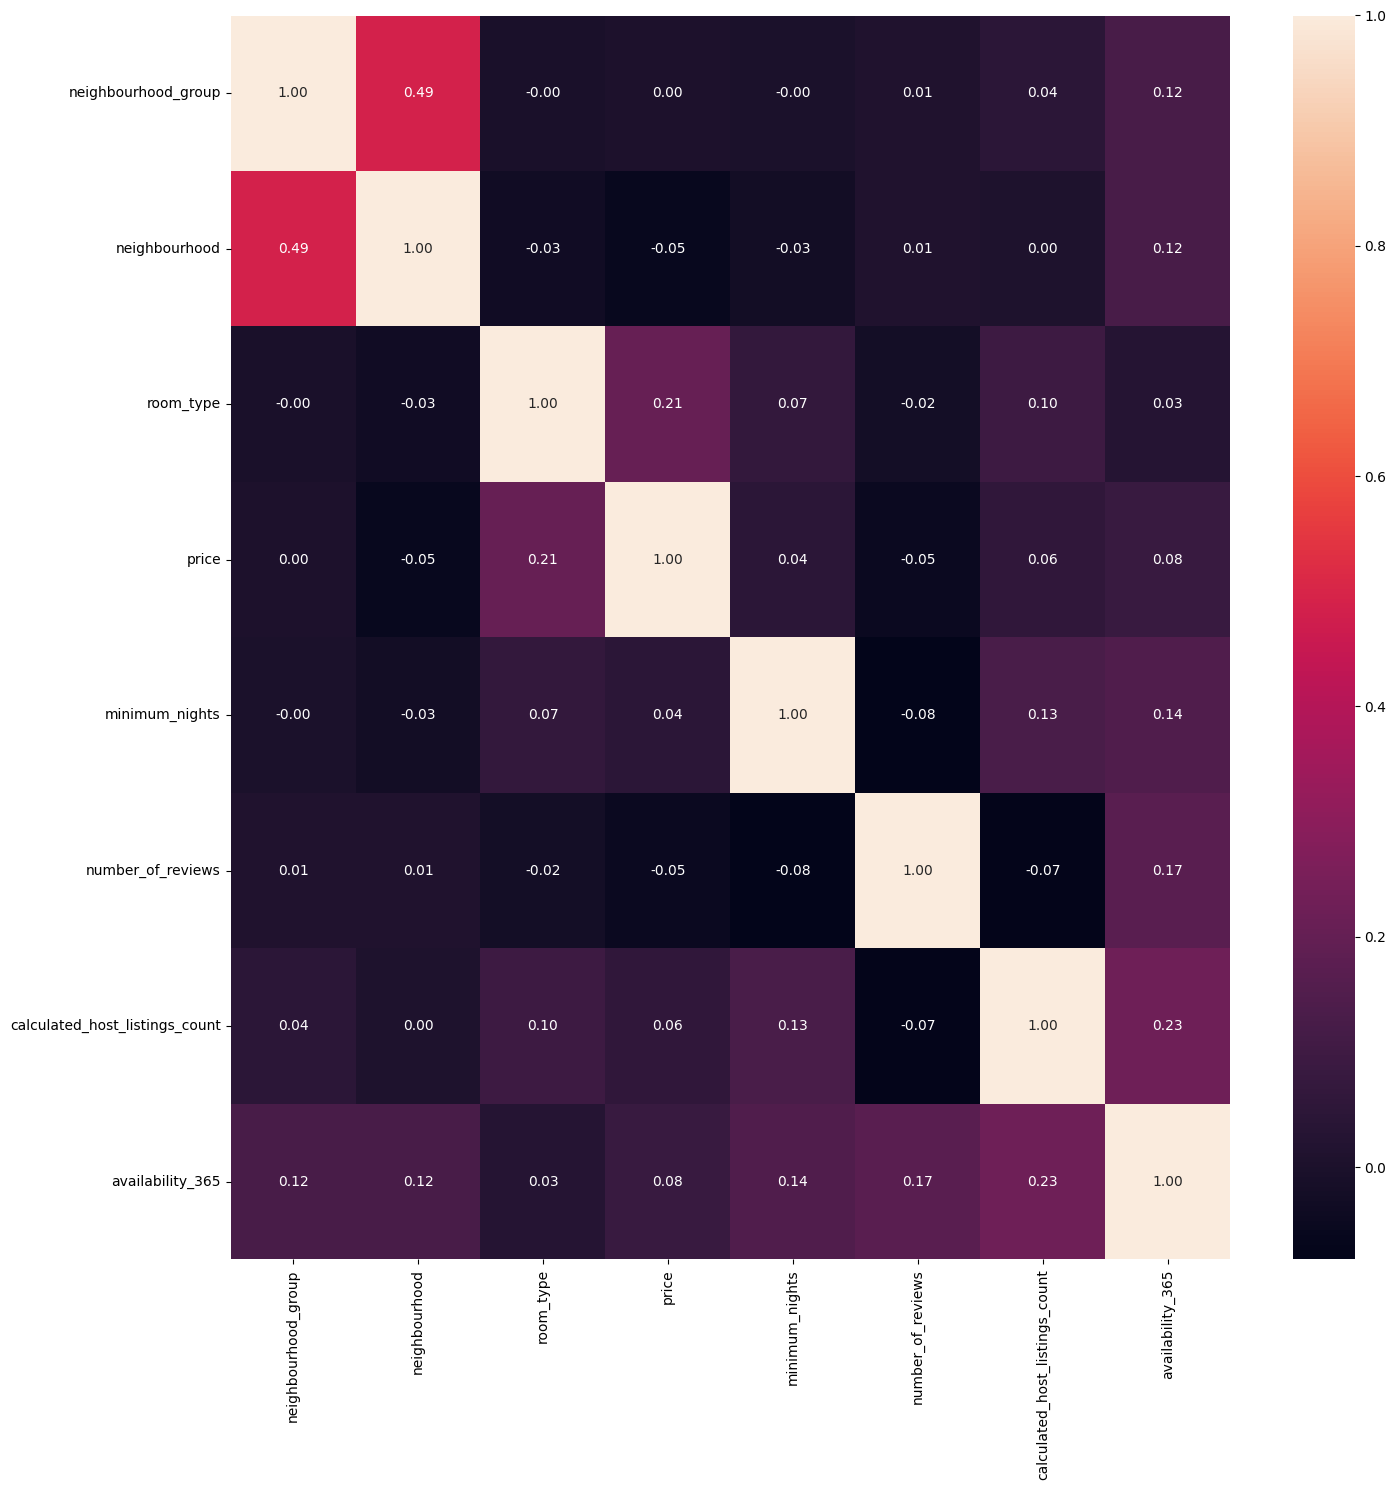

In [37]:
# Factorizar los datos del tipo de habitación y del barrio
total_data["room_type"] = pd.factorize(total_data["room_type"])[0]
total_data["neighbourhood_group"] = pd.factorize(total_data["neighbourhood_group"])[0]
total_data["neighbourhood"] = pd.factorize(total_data["neighbourhood"])[0]

fig, axes = plt.subplots(figsize=(15, 15))

sns.heatmap(total_data[["neighbourhood_group", "neighbourhood", "room_type", "price", "minimum_nights",
                        "number_of_reviews", "calculated_host_listings_count", "availability_365"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

# Draw Plot
plt.show()

Análisis de toda la data en una sola

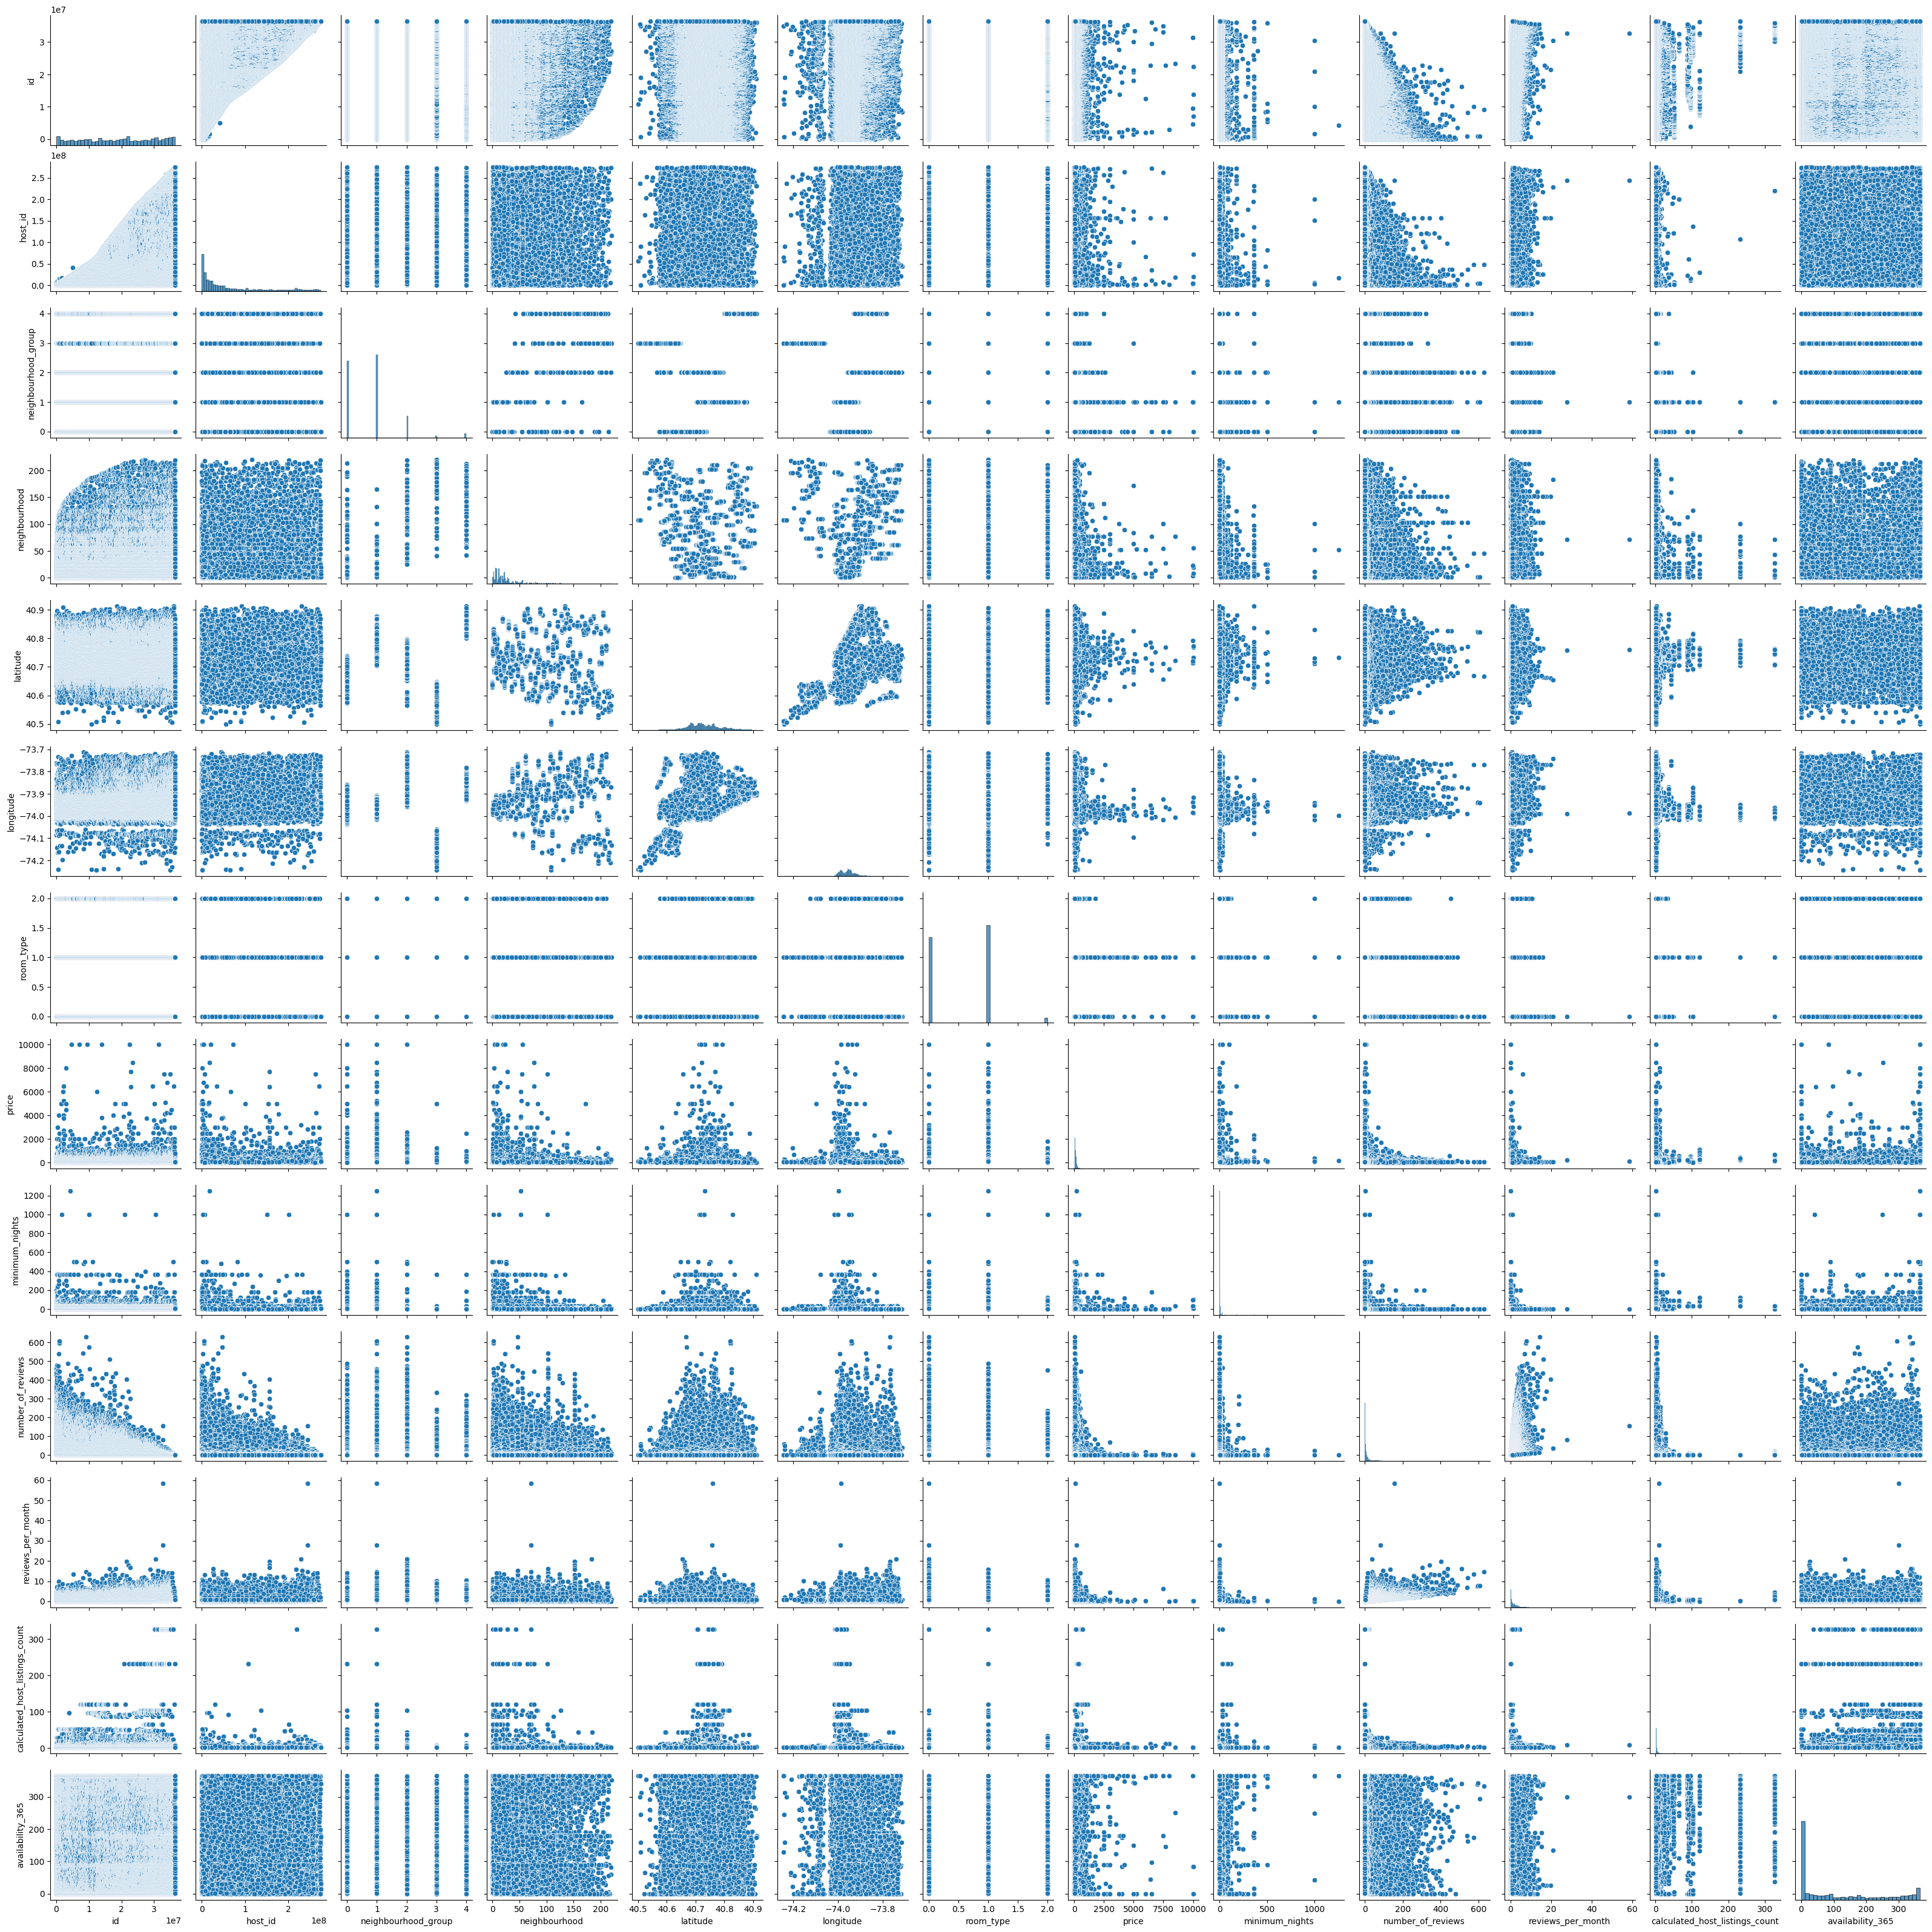

In [38]:
sns.pairplot(data = total_data)

Paso 5: Ingeniería de características

In [39]:
total_data.describe()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,0.786911,29.888782,40.728949,-73.952170,0.567113,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.844386,34.676634,0.054530,0.046157,0.541249,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,0.000000,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,0.000000,7.500000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,1.000000,19.000000,40.723070,-73.955680,1.000000,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,1.000000,37.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,4.000000,220.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


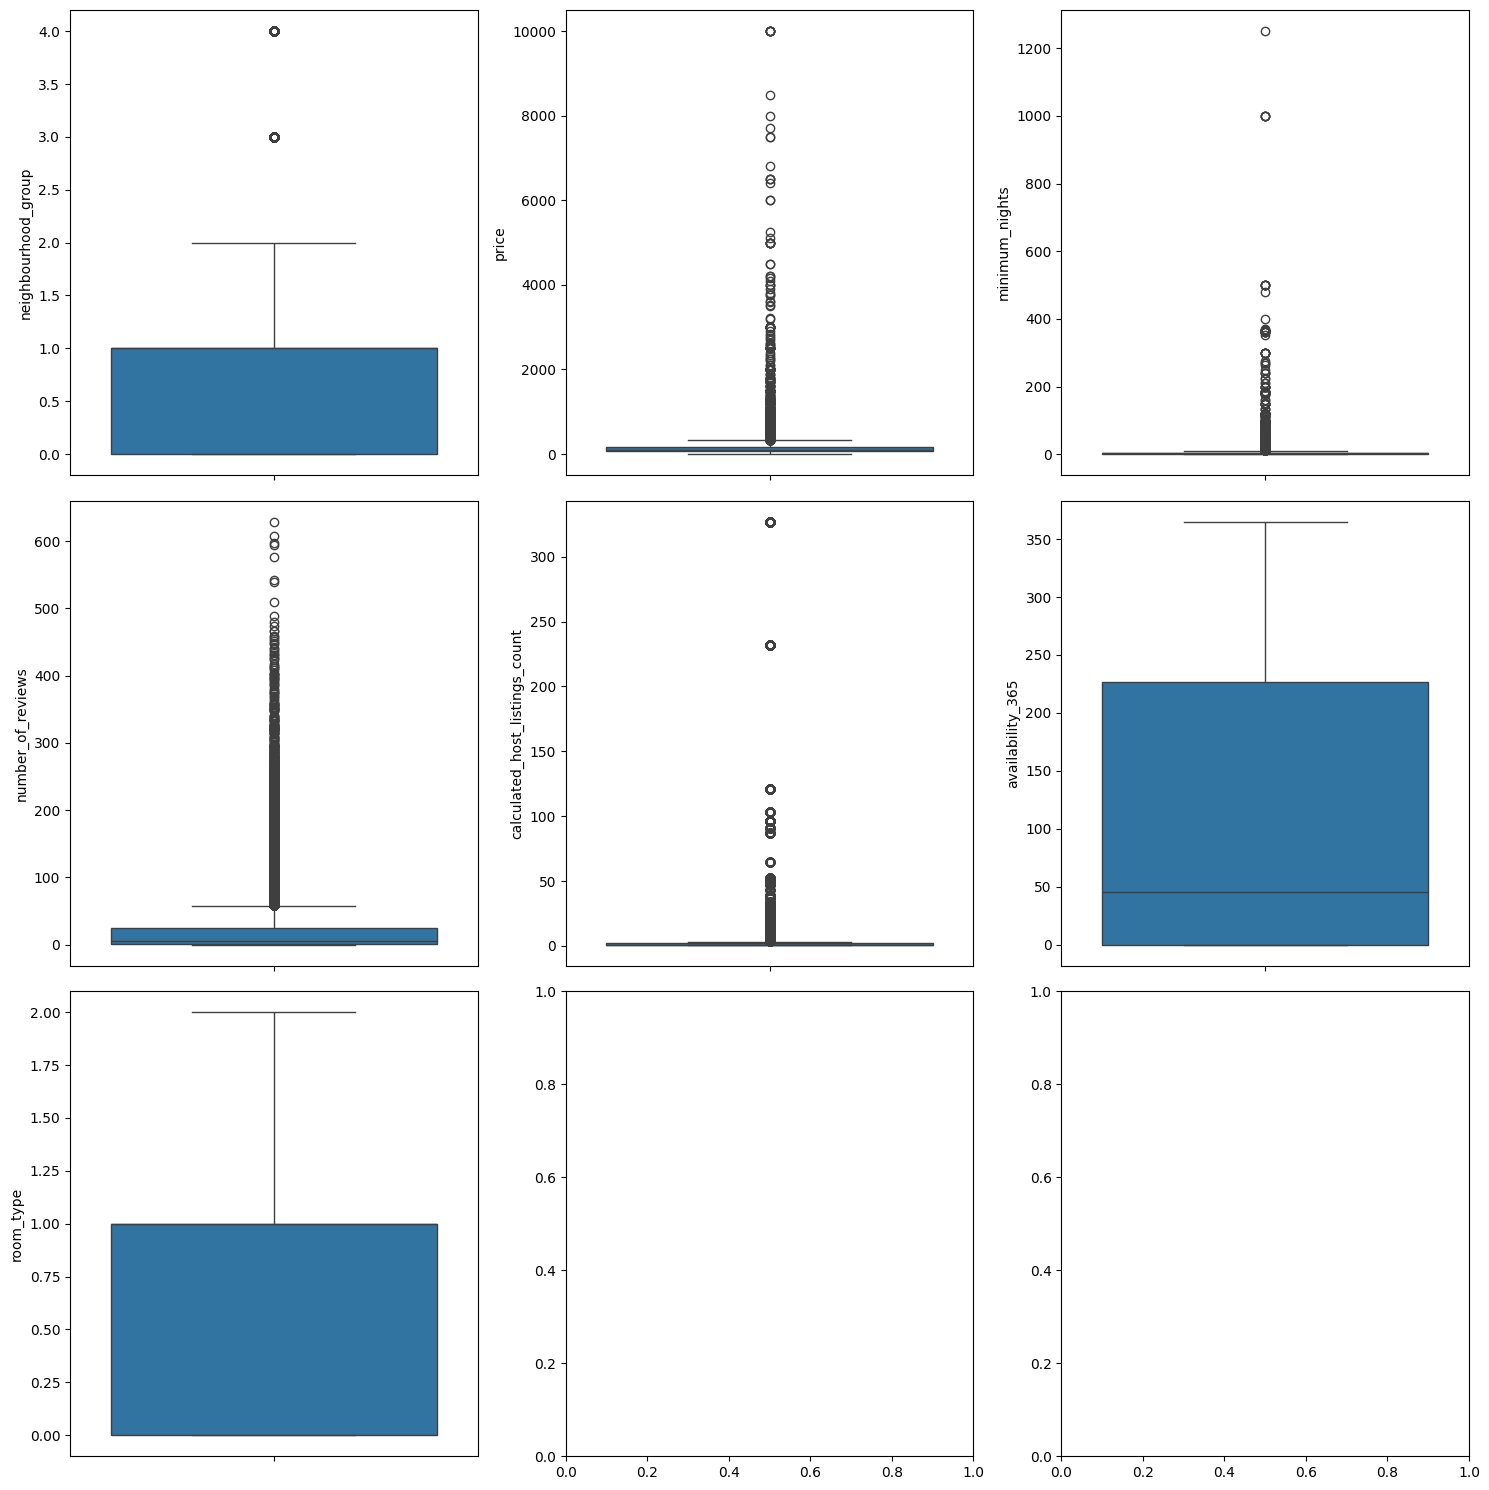

In [40]:
fig, axes = plt.subplots(3, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "neighbourhood_group")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "price")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "minimum_nights")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "number_of_reviews")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "calculated_host_listings_count")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "availability_365")
sns.boxplot(ax = axes[2, 0], data = total_data, y = "room_type")

plt.tight_layout()

plt.show()

In [41]:
# Stats for Price
price_stats = total_data["price"].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [42]:
# IQR para Price

price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(price_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 334.0 y -90.0, con un rango intercuartílico de 106.0


In [ ]:
##Limpieza de outliers
total_data[total_data["price"] > 300]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
61,15396,Sunny & Spacious Chelsea Apartment,60278,Petra,1,14,40.74623,-73.99530,1,375,180,5,2018-11-03,0.12,1,180
85,19601,perfect for a family or small group,74303,Maggie,0,32,40.69723,-73.99268,1,800,1,25,2016-08-04,0.24,1,7
103,23686,2000 SF 3br 2bath West Village private townhouse,93790,Ann,1,11,40.73096,-74.00319,1,500,4,46,2019-05-18,0.55,2,243
114,26933,2 BR / 2 Bath Duplex Apt with patio! East Village,72062,Bruce,1,19,40.72540,-73.98157,1,350,2,7,2017-08-09,0.06,4,298
116,26969,2 story family home in Williamsburg,115307,Alexandra,0,12,40.71942,-73.95748,1,325,3,324,2019-06-23,3.01,1,107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48758,36420289,"Rustic Garden House Apt, 2 stops from Manhattan",73211393,LaGabrell,2,25,40.75508,-73.93258,1,350,2,0,NaN,NaN,1,364
48833,36450896,Brand New 3-Bed Apt in the Best Location of FiDi,29741813,Yue,1,43,40.70605,-74.01042,1,475,2,0,NaN,NaN,1,64
48839,36452721,Massage Spa. Stay overnight. Authors Artist dr...,274079964,Richard,0,73,40.59866,-73.95661,0,800,1,0,NaN,NaN,1,23
48842,36453160,LUXURY MANHATTAN PENTHOUSE+HUDSON RIVER+EMPIRE...,224171371,LuxuryApartmentsByAmber,1,14,40.75204,-74.00292,1,350,1,0,NaN,NaN,1,9


Para la detección de valores sospechosos o erróneos, para algunos anfitriones les resulta más promocional colocar valores mínimos en el precio y luego posicionarse primeros en la búsqueda.

In [44]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["price", "minimum_nights", "number_of_reviews", "calculated_host_listings_count"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'price': [0, 334.0],
 'minimum_nights': [1, 11.0],
 'number_of_reviews': [0, 58.5],
 'calculated_host_listings_count': [1, 3.5]}

In [45]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [46]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [47]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [48]:
total_data_CON_outliers["price"] = total_data["price"].fillna(total_data["price"].median()) # Cuando una variable es entera pero numérica/incontable
total_data_CON_outliers["minimum_nights"] = total_data["minimum_nights"].fillna(total_data["minimum_nights"].median())
total_data_CON_outliers["number_of_reviews"]= total_data_CON_outliers["number_of_reviews"].fillna(total_data["number_of_reviews"].median())
total_data_CON_outliers.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Inferencia con nuevas características

In [49]:
total_data_CON_outliers["Best_rated"] = total_data_CON_outliers["host_name"] + total_data_CON_outliers["last_review"]
total_data_SIN_outliers["Best_rated"] = total_data_SIN_outliers["host_name"] + total_data_SIN_outliers["last_review"]

total_data_SIN_outliers.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Best_rated
0,2539,Clean & quiet apt home by the park,2787,John,0,0,40.64749,-73.97237,0,149.0,1.0,9.0,2018-10-19,0.21,3.5,365,John2018-10-19
1,2595,Skylit Midtown Castle,2845,Jennifer,1,1,40.75362,-73.98377,1,225.0,1.0,45.0,2019-05-21,0.38,2.0,355,Jennifer2019-05-21
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,1,2,40.80902,-73.94190,0,150.0,3.0,0.0,NaN,NaN,1.0,365,NaN
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,0,3,40.68514,-73.95976,1,89.0,1.0,58.5,2019-07-05,4.64,1.0,194,LisaRoxanne2019-07-05
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,1,4,40.79851,-73.94399,1,80.0,10.0,9.0,2018-11-19,0.10,1.0,0,Laura2018-11-19


In [50]:
from sklearn.model_selection import train_test_split

# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["neighbourhood", "neighbourhood_group", "room_type", "number_of_reviews", "calculated_host_listings_count"]
target = "price"

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)


In [51]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal